<a href="https://colab.research.google.com/github/SreeRam-TR/SRP-Project/blob/main/Gender%20Identification%20and%20Age%20prediction%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/utkface-new


In [6]:
id2gender = {
    0: 'male',
    1: 'female'
}

In [7]:
dataroot = '/kaggle/input/utkface-new'

In [8]:
from pathlib import Path

In [9]:
dataroot = Path(dataroot)

In [10]:
files = sorted((dataroot / 'UTKFace').glob("*.jpg"))
len(files)

23708

In [11]:
files_part = sorted((dataroot / 'crop_part1').glob("*.jpg"))
len(files_part)

9780

In [12]:
duplicates = set([f.name for f in files]) & set([f.name for f in files_part])
len(duplicates)

9779

In [13]:
set([f.name for f in files_part]) - set(duplicates)

{'61_3_20170109150557335.jpg.chip.jpg'}

In [14]:
f = files[0]
f.name

'100_0_0_20170112213500903.jpg.chip.jpg'

In [15]:
type(f.name)

str

In [16]:
parts = f.name.split('.')[0].split('_')
print(parts)
print(str(f.resolve()))
def parse_filename(f):
    parts = f.name.split('.')[0].split('_')
    age = int(parts[0])
    gender = int(parts[1])
    return str(f.resolve()), age, gender
data = [parse_filename(f) for f in files_part]
print(data[:10])

['100', '0', '0', '20170112213500903']
/kaggle/input/utkface-new/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg
[('/kaggle/input/utkface-new/crop_part1/100_1_0_20170110183726390.jpg.chip.jpg', 100, 1), ('/kaggle/input/utkface-new/crop_part1/100_1_2_20170105174847679.jpg.chip.jpg', 100, 1), ('/kaggle/input/utkface-new/crop_part1/101_1_2_20170105174739309.jpg.chip.jpg', 101, 1), ('/kaggle/input/utkface-new/crop_part1/10_0_0_20161220222308131.jpg.chip.jpg', 10, 0), ('/kaggle/input/utkface-new/crop_part1/10_0_0_20170103200329407.jpg.chip.jpg', 10, 0), ('/kaggle/input/utkface-new/crop_part1/10_0_0_20170103200522151.jpg.chip.jpg', 10, 0), ('/kaggle/input/utkface-new/crop_part1/10_0_0_20170103233459275.jpg.chip.jpg', 10, 0), ('/kaggle/input/utkface-new/crop_part1/10_0_0_20170104013211746.jpg.chip.jpg', 10, 0), ('/kaggle/input/utkface-new/crop_part1/10_0_0_20170110215927291.jpg.chip.jpg', 10, 0), ('/kaggle/input/utkface-new/crop_part1/10_0_0_20170110220033115.jpg.chip.jpg', 10, 0)]


In [17]:
import pandas as pd
df = pd.DataFrame(data, columns=['file', 'age', 'gender'])
df

,file,age,gender
0,/kaggle/input/utkface-new/crop_part1/100_1_0_2...,100,1
1,/kaggle/input/utkface-new/crop_part1/100_1_2_2...,100,1
2,/kaggle/input/utkface-new/crop_part1/101_1_2_2...,101,1
3,/kaggle/input/utkface-new/crop_part1/10_0_0_20...,10,0
4,/kaggle/input/utkface-new/crop_part1/10_0_0_20...,10,0
...,...,...,...
9775,/kaggle/input/utkface-new/crop_part1/9_1_3_201...,9,1
9776,/kaggle/input/utkface-new/crop_part1/9_1_3_201...,9,1
9777,/kaggle/input/utkface-new/crop_part1/9_1_4_201...,9,1
9778,/kaggle/input/utkface-new/crop_part1/9_1_4_201...,9,1


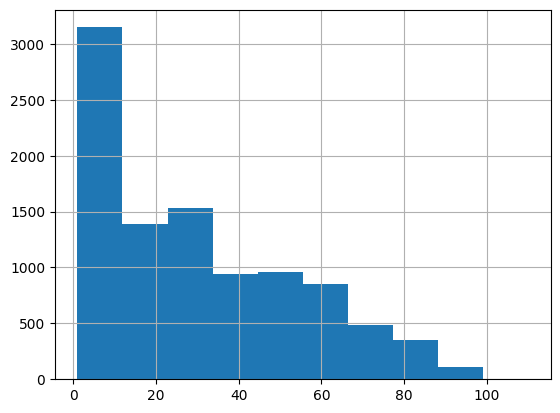

In [18]:
df['age'].hist();

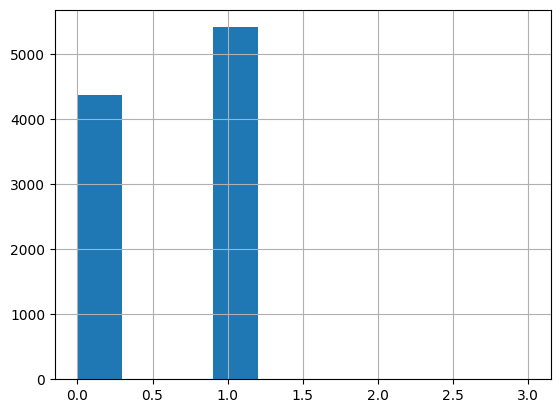

In [19]:
df['gender'].hist();

In [20]:
len(df)

9780

In [21]:
idx = 0
sample = df.iloc[idx]
sample

,0
file,/kaggle/input/utkface-new/crop_part1/100_1_0_2...
age,100
gender,1


In [22]:
file = sample['file']
age = sample['age']
gender = sample['gender']
print(file, age, gender)

/kaggle/input/utkface-new/crop_part1/100_1_0_20170110183726390.jpg.chip.jpg 100 1


In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class GenderAgeClass(Dataset):
  def __init__(self, df, transform=None):
    self.df = df
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    sample = self.df.iloc[idx]
    age = torch.Tensor([float(sample['age']/100)])
    gender = torch.Tensor([int(sample['gender'])])
    image = Image.open(sample['file'])
    if self.transform:
      image = self.transform(image)
    return image, age, gender

In [24]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [25]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import timm
model = timm.create_model("vgg16", pretrained=True).to(device)
data_cfg = timm.data.resolve_data_config(model.pretrained_cfg)
transform = timm.data.create_transform(**data_cfg)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

In [26]:
train_dataset = GenderAgeClass(train_df, transform=transform)
val_dataset = GenderAgeClass(val_df, transform=transform)
spl = train_dataset[0]
spl[0].shape, spl[1], spl[2]

(torch.Size([3, 224, 224]), tensor([0.0800]), tensor([1.]))

In [27]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, drop_last=False)
batch = next(iter(train_loader))
img, age, gender = batch
img, age, gender = img.to(device), age.to(device), gender.to(device)
img.shape, age.shape, gender.shape

(torch.Size([2, 3, 224, 224]), torch.Size([2, 1]), torch.Size([2, 1]))

In [28]:
img.dtype, age.dtype, gender.dtype

(torch.float32, torch.float32, torch.float32)

In [29]:
model(img).shape

torch.Size([2, 1000])

In [30]:
model.features(img).shape

torch.Size([2, 512, 7, 7])

In [31]:
model.forward_features(img).shape

torch.Size([2, 512, 7, 7])

In [32]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [33]:
from torch import nn


In [34]:
class ageGenderClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.intermediate = nn.Sequential(
            nn.Linear(4096,512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,64),
            nn.ReLU(),
        )
        self.age_classifier = nn.Sequential(
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        self.gender_classifier = nn.Sequential(
            nn.Linear(64, 1),
        )
    def forward(self, x):
        x = self.intermediate(x)
        age = self.age_classifier(x)
        gender = self.gender_classifier(x)
        return age, gender
model.head.fc = ageGenderClassifier()
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [35]:
model = model.to(device)
age_pred, gender_pred = model(img)
age_pred.shape, gender_pred.shape

(torch.Size([2, 1]), torch.Size([2, 1]))

In [36]:
import numpy as np
age

tensor([[0.3100],
        [0.3100]], device='cuda:0')

In [37]:
age_pred

tensor([[0.5068],
        [0.5113]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [38]:
(age*100).type(torch.int)

tensor([[31],
        [31]], device='cuda:0', dtype=torch.int32)

In [39]:
(age_pred*100).type(torch.int)

tensor([[50],
        [51]], device='cuda:0', dtype=torch.int32)

In [40]:
torch.abs((age*100).type(torch.int) - (age_pred*100).type(torch.int)).float().mean()

tensor(19.5000, device='cuda:0')

In [41]:
gender

tensor([[1.],
        [0.]], device='cuda:0')

In [42]:
gender_pred

tensor([[0.0923],
        [0.0909]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [43]:
from torch.nn.functional import sigmoid
sigmoid(gender_pred)

tensor([[0.5231],
        [0.5227]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [44]:
(sigmoid(gender_pred)>0.5).type(torch.float)

tensor([[1.],
        [1.]], device='cuda:0')

In [45]:
(gender == (sigmoid(gender_pred)>0.5).type(torch.float)).float().mean()

tensor(0.5000, device='cuda:0')

In [46]:
age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
age_criterion(age_pred, age)

tensor(0.1990, device='cuda:0', grad_fn=<MeanBackward0>)

In [47]:

gender_criterion(gender_pred, gender)

tensor(0.6939, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [48]:
from tqdm import tqdm
import pickle
from torch.optim import Adam
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("vgg16", pretrained=True)
data_cfg = timm.data.resolve_data_config(model.pretrained_cfg)
transform = timm.data.create_transform(**data_cfg)
for param in model.parameters():
    param.requires_grad = False
model.head.fc = ageGenderClassifier()
model = model.to(device)

In [49]:
!pip install torchinfo

In [50]:
from torchinfo import summary
summary(model, input_data=img)

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [2, 1]                    --
├─Sequential: 1-1                        [2, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [2, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [2, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [2, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [2, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [2, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [2, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [2, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [2, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [2, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [2, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [2, 256, 56, 56]    

In [51]:
optimizer = Adam(model.parameters(), lr=1e-4)
train_dataset = GenderAgeClass(train_df, transform=transform)
val_dataset = GenderAgeClass(val_df, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, drop_last=False)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()

In [52]:
train_losses = []
val_losses = []
val_age_maes = []
val_gender_accuracies = []

loss_val_best = 1e3

n_epochs = 5
for epoch in range(n_epochs):
    print("Epoch", epoch)
    model.train()
    loss_train = 0
    for batch in tqdm(train_loader):
        optimizer.zero_grad()
        img, age, gender = batch
        img, age, gender = img.to(device), age.to(device), gender.to(device)
        age_pred, gender_pred = model(img)
        age_loss = age_criterion(age_pred, age)
        gender_loss = gender_criterion(gender_pred, gender)
        total_loss = gender_loss + age_loss
        total_loss.backward()
        optimizer.step()

        loss_train += total_loss.item()
    loss_train /= len(train_loader)
    train_losses.append(loss_train)

    model.eval()
    loss_val = 0
    age_mae_val = 0
    gender_accuracy_val = 0
    for batch in tqdm(val_loader):
        img, age, gender = batch
        img, age, gender = img.to(device), age.to(device), gender.to(device)
        with torch.inference_mode():
            age_pred, gender_pred = model(img)
        age_loss = age_criterion(age_pred, age)
        gender_loss = gender_criterion(gender_pred, gender)
        total_loss = gender_loss + age_loss
        loss_val += total_loss.item()

        true_age = (age*100).type(torch.int)
        pred_age = (age_pred*100).type(torch.int)
        age_mae_val += torch.abs(true_age-pred_age).float().mean().item()

        pred_gender = (sigmoid(gender_pred)>0.5).type(torch.float)
        gender_accuracy_val += (gender == pred_gender).float().mean().item()
    loss_val /= len(val_loader)
    age_mae_val /= len(val_loader)
    gender_accuracy_val /= len(val_loader)
    val_losses.append(loss_val)
    val_age_maes.append(age_mae_val)
    val_gender_accuracies.append(gender_accuracy_val)

    if loss_val < loss_val_best:
        print(f'{loss_val_best} -> {loss_val}')
        loss_val_best = loss_val
        torch.save(model.state_dict(), 'best_model.pt')

    results = {
        'train_losses':train_losses,
        'val_losses':val_losses,
        'val_age_maes':val_age_maes,
        'val_gender_accuracies':val_gender_accuracies,
    }
    with open('results.pkl', 'wb') as f:
        pickle.dump(results, f)

Epoch 0


100%|██████████| 92/92 [00:19<00:00,  4.77it/s]


1000.0 -> 0.5934702980777492
Epoch 1


100%|██████████| 92/92 [00:11<00:00,  7.69it/s]


0.5934702980777492 -> 0.5511242180414822
Epoch 2


...

0.5511242180414822 -> 0.5419010623641636
Epoch 3


100%|██████████| 92/92 [00:11<00:00,  7.69it/s]


0.5419010623641636 -> 0.5314238277142462
Epoch 4


100%|██████████| 92/92 [00:11<00:00,  7.76it/s]


0.5314238277142462 -> 0.5172639860083228


In [53]:
  with open('results.pkl', 'rb') as f:
    res = pickle.load(f)

In [54]:
import matplotlib.pyplot as plt

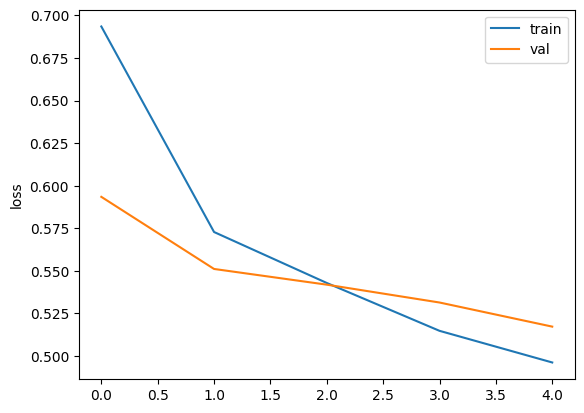

In [55]:
plt.plot(res['train_losses'], label='train')
plt.plot(res['val_losses'], label='val')
plt.ylabel('loss')
plt.legend();

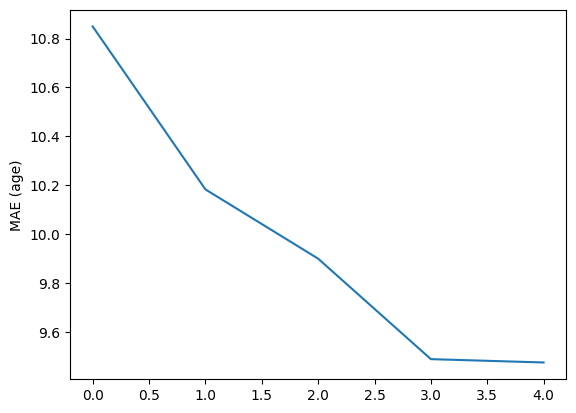

In [56]:
plt.plot(res['val_age_maes'])
plt.ylabel('MAE (age)');

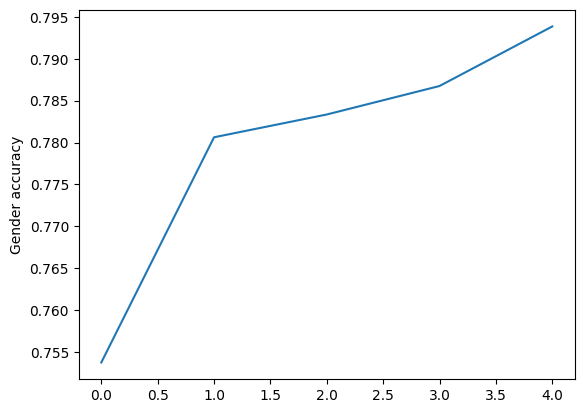

In [57]:
plt.plot(res['val_gender_accuracies'])
plt.ylabel('Gender accuracy');

In [58]:
model.load_state_dict(torch.load('best_model.pt', map_location=device, weights_only=True))

<All keys matched successfully>

In [59]:
test_dataset = GenderAgeClass(test_df, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=False)

model.eval()
loss_test = 0
age_mae_test = 0
gender_accuracy_test = 0
for batch in tqdm(test_loader):
    img, age, gender = batch
    img, age, gender = img.to(device), age.to(device), gender.to(device)
    with torch.inference_mode():
        age_pred, gender_pred = model(img)
    age_loss = age_criterion(age_pred, age)
    gender_loss = gender_criterion(gender_pred, gender)
    total_loss = gender_loss + age_loss
    loss_test += total_loss.item()

    true_age = (age*100).type(torch.int)
    pred_age = (age_pred*100).type(torch.int)
    age_mae_test += torch.abs(true_age-pred_age).float().mean().item()

    pred_gender = (sigmoid(gender_pred)>0.5).type(torch.float)
    gender_accuracy_test += (gender == pred_gender).float().mean().item()
loss_test /= len(test_loader)
age_mae_test /= len(test_loader)
gender_accuracy_test /= len(test_loader)

print("test loss", loss_test)
print("MAE (age)", age_mae_test)
print("Gender accuracy", gender_accuracy_test)


100%|██████████| 92/92 [00:20<00:00,  4.47it/s]

test loss 0.502526015367197
MAE (age) 8.81564970638441
Gender accuracy 0.8087944666976514


In [60]:
test_dataset = GenderAgeClass(test_df)

In [61]:
len(test_df)


1467

Age
True: 29
Pred: 35

Gender
True: female
Pred: female


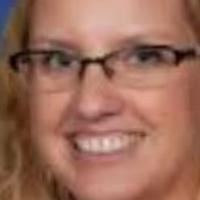

In [66]:

idx = np.random.choice(len(test_df))
sample = test_dataset[idx]
img, age, gender = sample

age_pred, gender_pred = model(transform(img).to(device).unsqueeze(0))
true_age = (age*100).type(torch.int).item()
pred_age = (age_pred*100).type(torch.int).item()

true_gender = id2gender[gender.item()]
pred_gender = id2gender[(sigmoid(gender_pred)>0.5).type(torch.float).item()]
print("Age")
print(f"True: {true_age}")
print(f"Pred: {pred_age}")
print()
print("Gender")
print(f"True: {true_gender}")
print(f"Pred: {pred_gender}")
img